In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\User\Downloads\salaries.csv",sep=',')

In [3]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,SE,FT,Data Product Owner,170000,USD,170000,US,0,US,M
1,2025,SE,FT,Data Product Owner,110000,USD,110000,US,0,US,M
2,2025,SE,FT,Data Product Owner,170000,USD,170000,US,0,US,M
3,2025,SE,FT,Data Product Owner,110000,USD,110000,US,0,US,M
4,2025,SE,FT,Engineer,143000,USD,143000,US,0,US,M


In [4]:
df.columns.tolist()

['work_year',
 'experience_level',
 'employment_type',
 'job_title',
 'salary',
 'salary_currency',
 'salary_in_usd',
 'employee_residence',
 'remote_ratio',
 'company_location',
 'company_size']

In [5]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,73148.000000,7.314800e+04,73148.000000,73148.000000
mean,2023.831192,1.625534e+05,158013.748619,21.582955
std,0.477551,1.925761e+05,72501.304728,41.023051
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.069575e+05,106890.000000,0.000000
50%,2024.000000,1.480000e+05,147500.000000,0.000000
75%,2024.000000,2.000000e+05,199700.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [6]:
df.dtypes

work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

In [7]:
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [8]:
df.shape

(73148, 11)

In [9]:
print(df['experience_level'].unique())

['SE' 'EN' 'MI' 'EX']


### EN: Entry-level / Junior
### MI: Mid-level / Intermediate
### SE: Senior-level / Expert
### EX: Executive-level / Director

In [10]:
print(df['employment_type'].unique())

['FT' 'PT' 'CT' 'FL']


### PT: Part-time
### FT: Full-time
### CT: Contract
### FL: Freelance

In [11]:
print(sorted(df['work_year'].unique()))

[2020, 2021, 2022, 2023, 2024, 2025]


In [12]:
print(df['job_title'].nunique()) # there are totally 289 unique jobs

289


In [13]:
print(df['company_location'].nunique()) #there are 86 different locations

86


In [14]:
print(df['experience_level'].value_counts())

experience_level
SE    42926
MI    21851
EN     6877
EX     1494
Name: count, dtype: int64


In [15]:
print(df['experience_level'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

experience_level
SE    58.68%
MI    29.87%
EN      9.4%
EX     2.04%
Name: proportion, dtype: object


In [16]:
fresher_df = df[df['experience_level'] == 'EN'].copy()

In [17]:
print('Total records',len(df))
print('Total fresher records',len(fresher_df))

Total records 73148
Total fresher records 6877


In [18]:
fresher_df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
8,2025,EN,FT,Data Scientist,49363,GBP,62484,GB,0,GB,M
9,2025,EN,FT,Data Scientist,41123,GBP,52054,GB,0,GB,M
14,2025,EN,FT,Data Scientist,126000,USD,126000,CA,0,CA,M
15,2025,EN,FT,Data Scientist,68700,USD,68700,CA,0,CA,M
28,2025,EN,FT,AI Engineer,124805,USD,124805,US,0,US,L


In [19]:
fresher_df.duplicated().sum()

2921

In [20]:
fresher_df = fresher_df.drop_duplicates()

In [21]:
fresher_df.duplicated().sum()

0

In [22]:
fresher_df = fresher_df[fresher_df['employment_type'] == 'FT']

In [23]:
print("Fresher Full-Time records after cleaning:", len(fresher_df))

Fresher Full-Time records after cleaning: 3830


In [24]:
fresher_df = fresher_df[fresher_df['work_year'] >= 2022]

In [25]:
print("Fresher records (2022 onwards):", len(fresher_df))

Fresher records (2022 onwards): 3770


In [26]:
print(fresher_df['work_year'].value_counts().sort_index())

work_year
2022      95
2023     346
2024    3285
2025      44
Name: count, dtype: int64


In [27]:
print("Top 15 Jobs for Freshers:\n")
print(fresher_df['job_title'].value_counts().head(15))

Top 15 Jobs for Freshers:

job_title
Data Analyst                     1192
Data Scientist                    298
Analyst                           295
Data Engineer                     232
Software Engineer                 139
Engineer                          138
Machine Learning Engineer         128
Business Intelligence Analyst     123
Research Analyst                  118
Research Scientist                 90
Business Analyst                   56
Research Engineer                  56
Data Management Analyst            48
Data Quality Analyst               38
Data Specialist                    38
Name: count, dtype: int64


In [28]:
# Save cleaned fresher data for next steps
fresher_df.to_csv('fresher_salaries.csv', index=False)

print("Cleaned fresher data saved as 'fresher_salaries.csv'")
print("Shape:", fresher_df.shape)

Cleaned fresher data saved as 'fresher_salaries.csv'
Shape: (3770, 11)


In [29]:
# Basic salary statistics for freshers
print("Fresher Salary Statistics (in USD):\n")
print(f"Average Salary  : ${fresher_df['salary_in_usd'].mean():,.0f}")
print(f"Median Salary   : ${fresher_df['salary_in_usd'].median():,.0f}")
print(f"Minimum Salary  : ${fresher_df['salary_in_usd'].min():,.0f}")
print(f"Maximum Salary  : ${fresher_df['salary_in_usd'].max():,.0f}")

Fresher Salary Statistics (in USD):

Average Salary  : $99,822
Median Salary   : $87,100
Minimum Salary  : $15,000
Maximum Salary  : $774,000


In [30]:
# Average salary per job title for freshers
job_salary = fresher_df.groupby('job_title')['salary_in_usd'].agg(['mean','min','max','count'])
job_salary.columns = ['Avg Salary', 'Min Salary', 'Max Salary', 'Total Jobs']
job_salary = job_salary.sort_values('Avg Salary', ascending=False).round(0)

print("Salary by Job Title (Top 15):\n")
print(job_salary.head(15).to_string())

Salary by Job Title (Top 15):

                                   Avg Salary  Min Salary  Max Salary  Total Jobs
job_title                                                                        
AI Researcher                        300000.0      250000      350000           2
Research Scientist                   185656.0       44850      560000          90
Machine Learning Model Engineer      180000.0      144000      216000           2
Quantitative Researcher              175000.0      150000      200000           2
Platform Engineer                    170750.0      119000      250000           6
Data Analytics Lead                  165350.0      132300      198400           2
Applied Scientist                    162435.0       76400      281700          33
Site Reliability Engineer            154907.0      106590      276000           6
Quantitative Analyst                 152716.0       40000      465972          10
Business Intelligence Lead           150748.0      114080      1874

In [31]:
# Top 15 countries by average fresher salary
country_salary = fresher_df.groupby('company_location')['salary_in_usd'].agg(['mean','count'])
country_salary.columns = ['Avg Salary', 'Job Count']
country_salary = country_salary[country_salary['Job Count'] >= 5]  # only countries with 5+ records
country_salary = country_salary.sort_values('Avg Salary', ascending=False).round(0)

print("Top 15 Countries by Fresher Salary:\n")
print(country_salary.head(15).to_string())

Top 15 Countries by Fresher Salary:

                  Avg Salary  Job Count
company_location                       
MX                  161683.0          6
US                  108632.0       2958
AU                   92918.0         39
CA                   90651.0        207
CH                   77396.0          9
DE                   72639.0         29
MT                   66825.0         12
IT                   66724.0          6
FR                   61910.0         39
AR                   61600.0          8
NL                   61344.0         32
GB                   59800.0        243
LT                   55478.0         20
IE                   54889.0         10
AT                   50834.0         13


In [32]:
# How fresher salaries changed year by year
yearly_salary = fresher_df.groupby('work_year')['salary_in_usd'].mean().round(0)

print(" Average Fresher Salary by Year:\n")
for year, salary in yearly_salary.items():
    print(f"  {year}  →  ${salary:,.0f}")

 Average Fresher Salary by Year:

  2022  →  $72,291
  2023  →  $90,310
  2024  →  $101,818
  2025  →  $85,077


In [33]:
# Does remote work affect fresher salary?
remote_map = {0: 'On-site', 50: 'Hybrid', 100: 'Fully Remote'}
fresher_df['remote_type'] = fresher_df['remote_ratio'].map(remote_map)

remote_salary = fresher_df.groupby('remote_type')['salary_in_usd'].mean().round(0).sort_values(ascending=False)

print("Average Fresher Salary by Work Type:\n")
for work_type, salary in remote_salary.items():
    print(f"  {work_type:<15} →  ${salary:,.0f}")

Average Fresher Salary by Work Type:

  On-site         →  $103,246
  Fully Remote    →  $88,278
  Hybrid          →  $61,318


In [34]:
# Does company size affect fresher salary?
size_map = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}
fresher_df['company_size_label'] = fresher_df['company_size'].map(size_map)

size_salary = fresher_df.groupby('company_size_label')['salary_in_usd'].mean().round(0).sort_values(ascending=False)

print("Average Fresher Salary by Company Size:\n")
for size, salary in size_salary.items():
    print(f"  {size:<20} →  ${salary:,.0f}")

Average Fresher Salary by Company Size:

  Medium               →  $100,415
  Large                →  $93,517
  Small                →  $59,242


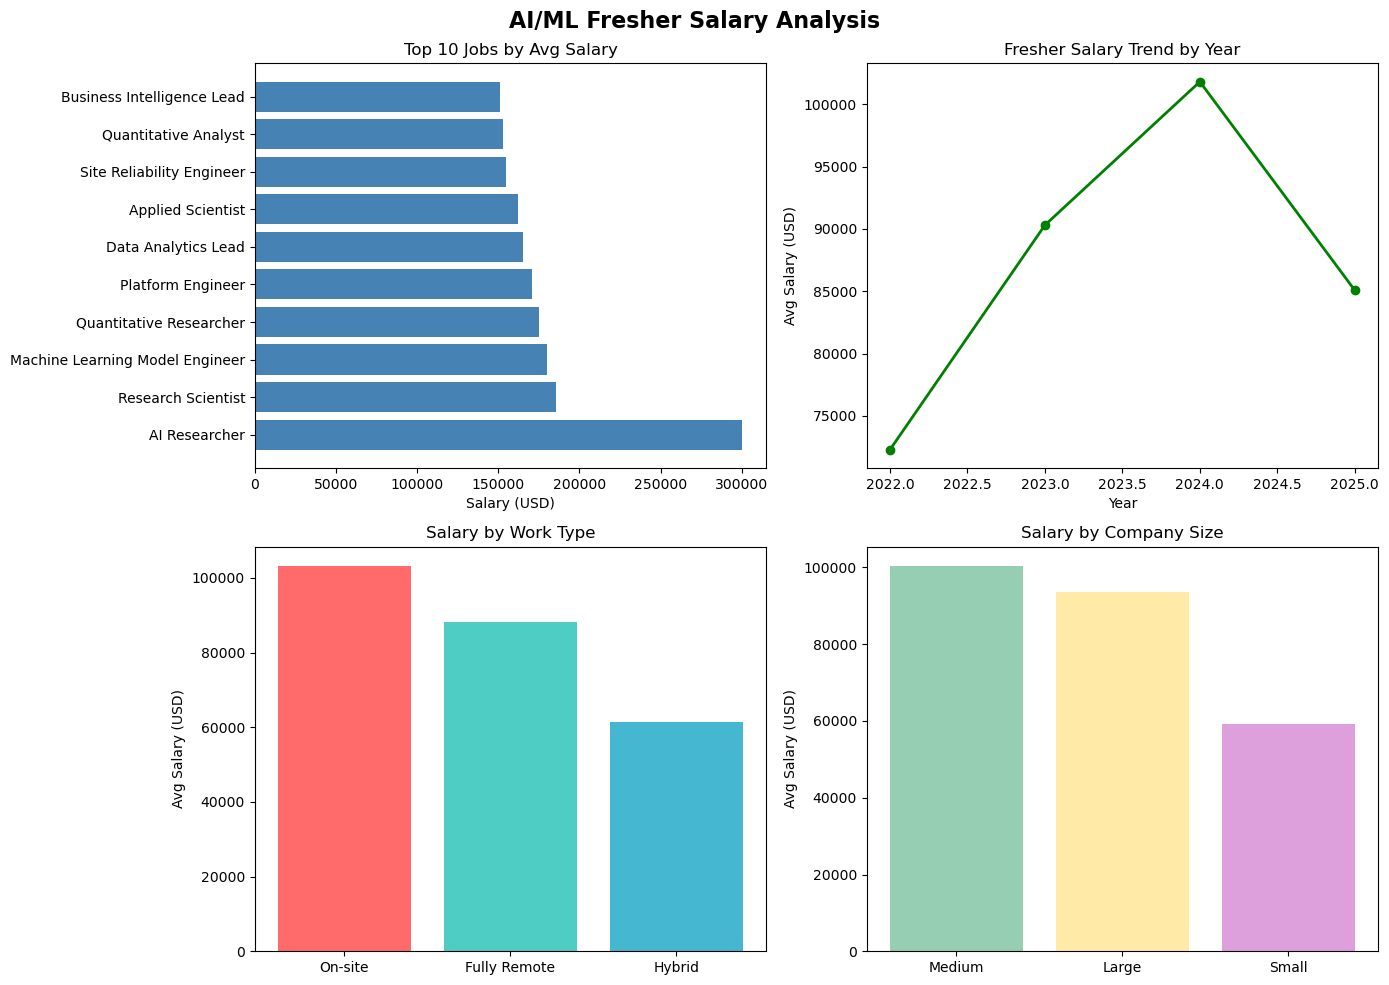

Chart saved as 'fresher_salary_analysis.png'


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('AI/ML Fresher Salary Analysis', fontsize=16, fontweight='bold')

# 1. Top 10 Jobs by Salary
top_jobs = job_salary.head(10)
axes[0,0].barh(top_jobs.index, top_jobs['Avg Salary'], color='steelblue')
axes[0,0].set_title('Top 10 Jobs by Avg Salary')
axes[0,0].set_xlabel('Salary (USD)')

# 2. Salary Trend by Year
axes[0,1].plot(yearly_salary.index, yearly_salary.values, marker='o', color='green', linewidth=2)
axes[0,1].set_title('Fresher Salary Trend by Year')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Avg Salary (USD)')

# 3. Remote Work vs Salary
axes[1,0].bar(remote_salary.index, remote_salary.values, color=['#FF6B6B','#4ECDC4','#45B7D1'])
axes[1,0].set_title('Salary by Work Type')
axes[1,0].set_ylabel('Avg Salary (USD)')

# 4. Company Size vs Salary
axes[1,1].bar(size_salary.index, size_salary.values, color=['#96CEB4','#FFEAA7','#DDA0DD'])
axes[1,1].set_title('Salary by Company Size')
axes[1,1].set_ylabel('Avg Salary (USD)')

plt.tight_layout()
plt.savefig('fresher_salary_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'fresher_salary_analysis.png'")

In [36]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [45]:
# Fix DNS issue
import os
os.environ['NO_PROXY'] = '*'
os.environ['CURL_CA_BUNDLE'] = ''

import requests
requests.packages.urllib3.disable_warnings()

r = requests.get("https://huggingface.co", verify=False, timeout=10)
print("Status:", r.status_code)

Status: 200


In [38]:
from huggingface_hub import InferenceClient

HF_TOKEN = "#################"  # your token

# This model works without any approval
client = InferenceClient(
    model="Qwen/Qwen2.5-72B-Instruct",
    token=HF_TOKEN
)

# Test
response = client.chat_completion(
    messages=[
        {"role": "user", "content": "What is a Data Scientist?"}
    ],
    max_tokens=200
)

print("🤖 AI Response:\n")
print(response.choices[0].message.content)

🤖 AI Response:

A Data Scientist is a professional who specializes in extracting insights and knowledge from data. They use a combination of statistical analysis, machine learning, and data visualization techniques to help businesses and organizations make data-driven decisions. Here are some key aspects of a Data Scientist's role:

### 1. **Data Collection and Preparation**
   - **Data Collection:** Gathering data from various sources, which can include databases, APIs, web scraping, and more.
   - **Data Cleaning:** Ensuring the data is accurate and consistent by handling missing values, removing duplicates, and correcting errors.
   - **Data Transformation:** Converting data into a format suitable for analysis, such as normalizing, scaling, or encoding categorical variables.

### 2. **Data Analysis**
   - **Statistical Analysis:** Using statistical methods to explore and understand the data, including hypothesis testing, regression analysis, and correlation studies.
   - **Explorato

In [39]:
import warnings
warnings.filterwarnings('ignore')
requests.packages.urllib3.disable_warnings()

# Load cleaned fresher data
fresher_df = pd.read_csv('fresher_salaries.csv')

print("✅ Data loaded!", fresher_df.shape)

✅ Data loaded! (3770, 11)


In [40]:
# This function pulls real salary data for the AI to use
def get_salary_context(job_title, country=None):
    
    # Filter by job title (partial match)
    mask = fresher_df['job_title'].str.contains(job_title, case=False, na=False)
    filtered = fresher_df[mask]
    
    if len(filtered) == 0:
        # If no exact match, use all fresher data
        filtered = fresher_df
        job_info = "General AI/ML fresher roles"
    else:
        job_info = job_title
    
    # Overall stats
    avg_salary  = filtered['salary_in_usd'].mean()
    min_salary  = filtered['salary_in_usd'].min()
    max_salary  = filtered['salary_in_usd'].max()
    
    # Country specific
    country_info = ""
    if country:
        country_data = filtered[filtered['company_location'] == country.upper()]
        if len(country_data) > 0:
            country_avg = country_data['salary_in_usd'].mean()
            country_info = f"In {country}, average fresher salary is ${country_avg:,.0f}/year."
    
    # Top paying countries
    top_countries = filtered.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=False).head(5)
    top_countries_str = ", ".join([f"{c}(${s:,.0f})" for c, s in top_countries.items()])
    
    # Remote info
    remote_salary = filtered[filtered['remote_ratio'] == 100]['salary_in_usd'].mean()
    onsite_salary = filtered[filtered['remote_ratio'] == 0]['salary_in_usd'].mean()
    
    context = f"""
    Role: {job_info}
    Total Records: {len(filtered)}
    Average Fresher Salary: ${avg_salary:,.0f}/year
    Salary Range: ${min_salary:,.0f} - ${max_salary:,.0f}/year
    {country_info}
    Top Paying Countries: {top_countries_str}
    Remote Work Avg Salary: ${remote_salary:,.0f}/year
    Onsite Avg Salary: ${onsite_salary:,.0f}/year
    """
    
    return context

# Test it
print(get_salary_context("Data Scientist", "US"))


    Role: Data Scientist
    Total Records: 304
    Average Fresher Salary: $97,191/year
    Salary Range: $16,000 - $250,200/year
    In US, average fresher salary is $108,545/year.
    Top Paying Countries: EG($158,300), CH($113,331), US($108,545), CA($101,247), BE($68,030)
    Remote Work Avg Salary: $84,034/year
    Onsite Avg Salary: $104,439/year
    


In [41]:
from huggingface_hub import InferenceClient

HF_TOKEN = "#####################"  #your token

client = InferenceClient(
    model="Qwen/Qwen2.5-72B-Instruct",
    token=HF_TOKEN
)

def career_coach(user_name, job_interest, country, skills):
    
    # Get real salary data
    salary_context = get_salary_context(job_interest, country)
    
    # Build the prompt
    prompt = f"""
    You are an expert AI Career Coach for freshers in the AI/ML and Data Science field.
    Use the real salary data below to give accurate, helpful advice.
    
    === REAL SALARY DATA FROM DATASET ===
    {salary_context}
    
    === FRESHER PROFILE ===
    Name        : {user_name}
    Interested  : {job_interest}
    Country     : {country}
    Skills      : {skills}
    
    === YOUR TASK ===
    Give a personalized career coaching response that includes:
    1. 🎯 Is this a good career choice? Why?
    2. 💰 Realistic salary expectation for fresher in {country}
    3. 📚 Top 5 skills they should learn
    4. 🗺️ Career growth path (Fresher → Senior)
    5. 💡 3 Practical tips to get first job
    
    Keep the tone friendly, motivating and practical.
    Use the real salary numbers from the data provided.
    """
    
    response = client.chat_completion(
        messages=[{"role": "user", "content": prompt}],
        max_tokens=800
    )
    
    return response.choices[0].message.content

print("✅ Career Coach function ready!")

✅ Career Coach function ready!


In [42]:
# AI CAREER COACH FOR FRESHERS

print("=" * 50)
print("      🤖 AI CAREER COACH FOR FRESHERS")
print("=" * 50)

# Fill in your details here
user_name   = "Sandy"                          # your name
job_title   = "Data Scientist"                # job you want
country     = "IN"                            # your country code
my_skills   = "Python, Excel, basic ML"       # your current skills

print(f"\n👤 Name    : {user_name}")
print(f"💼 Role    : {job_title}")
print(f"🌍 Country : {country}")
print(f"🛠️  Skills  : {my_skills}")
print("\n⏳ Getting your personalized career advice...\n")

# Get AI advice
advice = career_coach(user_name, job_title, country, my_skills)

print("=" * 50)
print("         🎯 YOUR CAREER ROADMAP")
print("=" * 50)
print(advice)
print("=" * 50)

      🤖 AI CAREER COACH FOR FRESHERS

👤 Name    : Sandy
💼 Role    : Data Scientist
🌍 Country : IN
🛠️  Skills  : Python, Excel, basic ML

⏳ Getting your personalized career advice...

         🎯 YOUR CAREER ROADMAP
Hey Sandy!

It’s great to see your interest in becoming a Data Scientist. Let's dive into some personalized advice to help you navigate this exciting journey.

### 🎯 Is This a Good Career Choice? Why?
Absolutely, Sandy! Data Science is a fantastic career choice for several reasons:
- **High Demand**: The field is rapidly growing, and companies across industries are increasingly investing in data-driven solutions.
- **Competitive Salaries**: Even for freshers, the salaries are competitive, and there’s a lot of room for growth.
- **Diverse Applications**: You can apply your skills in various sectors, from tech and finance to healthcare and marketing.
- **Continuous Learning**: The field is ever-evolving, which means you’ll always have new challenges and learning opportunities.


# It Is a Interactive version above code

In [46]:
# Interactive version - ask for user input
print("=" * 50)
print("    🤖 AI CAREER COACH - INTERACTIVE MODE")
print("=" * 50)

user_name  = input("👤 Enter your name: ")
job_title  = input("💼 What job role interests you? (e.g. Data Scientist): ")
country    = input("🌍 Your country code (e.g. IN, US, GB): ").upper()
my_skills  = input("🛠️  List your current skills: ")

print("\n⏳ Analyzing your profile...\n")

advice = career_coach(user_name, job_title, country, my_skills)

print("\n" + "=" * 50)
print("         🎯 YOUR CAREER ROADMAP")
print("=" * 50)
print(advice)
print("=" * 50)

    🤖 AI CAREER COACH - INTERACTIVE MODE


👤 Enter your name:  s
💼 What job role interests you? (e.g. Data Scientist):  data science
🌍 Your country code (e.g. IN, US, GB):  in
🛠️  List your current skills:  Python, Excel, basic ML



⏳ Analyzing your profile...



ConnectError: [Errno 11002] getaddrinfo failed

In [47]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries ready!")

✅ Libraries ready!


In [48]:
# ============================================
#      🤖 AI CAREER COACH - CHAT INTERFACE
# ============================================

# --- Style ---
display(HTML("""
<style>
    .coach-title {
        background: linear-gradient(90deg, #667eea, #764ba2);
        color: white;
        padding: 20px;
        border-radius: 10px;
        text-align: center;
        font-size: 24px;
        font-weight: bold;
        margin-bottom: 20px;
    }
    .response-box {
        background: #f8f9fa;
        border-left: 5px solid #667eea;
        padding: 20px;
        border-radius: 8px;
        font-size: 15px;
        line-height: 1.8;
        margin-top: 15px;
    }
    .salary-box {
        background: #e8f5e9;
        border-left: 5px solid #4CAF50;
        padding: 15px;
        border-radius: 8px;
        margin-top: 10px;
    }
    .error-box {
        background: #ffebee;
        border-left: 5px solid #f44336;
        padding: 15px;
        border-radius: 8px;
        margin-top: 10px;
    }
</style>
"""))

# --- Title ---
display(HTML('<div class="coach-title">🤖 AI Career Coach for Freshers</div>'))

# --- Input Fields ---
name_input = widgets.Text(
    placeholder='Enter your name',
    description='👤 Name:',
    layout=widgets.Layout(width='500px'),
    style={'description_width': '120px'}
)

job_input = widgets.Text(
    placeholder='e.g. Data Scientist, AI Engineer, Data Analyst',
    description='💼 Job Role:',
    layout=widgets.Layout(width='500px'),
    style={'description_width': '120px'}
)

country_input = widgets.Dropdown(
    options=[
        ('India', 'IN'),
        ('United States', 'US'),
        ('United Kingdom', 'GB'),
        ('Canada', 'CA'),
        ('Germany', 'DE'),
        ('Australia', 'AU'),
        ('France', 'FR'),
        ('Singapore', 'SG'),
        ('Other', 'OTHER')
    ],
    value='IN',
    description='🌍 Country:',
    layout=widgets.Layout(width='500px'),
    style={'description_width': '120px'}
)

skills_input = widgets.Textarea(
    placeholder='e.g. Python, SQL, Machine Learning, Excel...',
    description='🛠️ Skills:',
    layout=widgets.Layout(width='500px', height='80px'),
    style={'description_width': '120px'}
)

# --- Button ---
submit_btn = widgets.Button(
    description='🚀 Get Career Advice',
    button_style='primary',
    layout=widgets.Layout(width='250px', height='45px')
)

# --- Output Area ---
output = widgets.Output()

# --- Button Click Function ---
def on_submit(btn):
    with output:
        clear_output()
        
        # Get values
        name    = name_input.value.strip()
        job     = job_input.value.strip()
        country = country_input.value
        skills  = skills_input.value.strip()
        
        # Validate inputs
        if not name or not job or not skills:
            display(HTML('<div class="error-box">⚠️ Please fill in all fields!</div>'))
            return
        
        # Show loading
        display(HTML('<div style="text-align:center; padding:20px; font-size:18px;">⏳ Analyzing your profile... Please wait...</div>'))
        
        try:
            # Get salary data
            salary_context = get_salary_context(job, country)
            
            # Show salary data
            display(HTML(f"""
            <div class="salary-box">
                <b>📊 Real Salary Data Found for "{job}":</b><br>
                {salary_context.replace(chr(10), '<br>')}
            </div>
            """))
            
            # Get AI advice
            advice = career_coach(name, job, country, skills)
            
            # Show response
            display(HTML(f"""
            <div class="response-box">
                <b>🎯 Your Personalized Career Roadmap:</b><br><br>
                {advice.replace(chr(10), '<br>')}
            </div>
            """))
            
        except Exception as e:
            display(HTML(f'<div class="error-box">❌ Error: {str(e)}</div>'))

# --- Connect button to function ---
submit_btn.on_click(on_submit)

# --- Display Everything ---
display(name_input)
display(job_input)
display(country_input)
display(skills_input)
display(submit_btn)
display(output)

Text(value='', description='👤 Name:', layout=Layout(width='500px'), placeholder='Enter your name', style=TextS…

Text(value='', description='💼 Job Role:', layout=Layout(width='500px'), placeholder='e.g. Data Scientist, AI E…

Dropdown(description='🌍 Country:', layout=Layout(width='500px'), options=(('India', 'IN'), ('United States', '…

Textarea(value='', description='🛠️ Skills:', layout=Layout(height='80px', width='500px'), placeholder='e.g. Py…

Button(button_style='primary', description='🚀 Get Career Advice', layout=Layout(height='45px', width='250px'),…

Output()